# 📊 Сравнение Ridge-регрессии с наивными прогнозами (CPU)

Ноутбук сравнивает финальную Ridge-модель (горизонт 5 мин) с **Naive Last** — прогноз = последнее известное значение (shift(h))

Оценка проводится через **walk-forward cross-validation** (5 фолдов, схема 2).


## 1. Настройка окружения


In [44]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Константы (должны совпадать с cpu_walkforward.ipynb) ─────────────────
FREQ_SEC             = 15
DATA_PATH            = 'data/cpu_dataset.csv'
FINAL_HORIZON_MIN    = 5
FINAL_HORIZON_STEPS  = int(FINAL_HORIZON_MIN * 60 / FREQ_SEC)  # 20
LAGS                 = [1, 2, 4, 8, 16, 32, 60, 120, 240]
ROLL_WINDOWS         = [4, 20, 60, 120, 240]
EWM_SPANS            = [4, 20, 60]
ALPHA_RIDGE          = 10.0
N_FOLDS              = 5

MIN_HISTORY_POINTS = max(max(LAGS), max(ROLL_WINDOWS)) + 1  # 241

FEATURE_COLS = (
    [f'lag_{l}' for l in LAGS]
    + [f'roll_mean_{w}' for w in ROLL_WINDOWS]
    + [f'roll_std_{w}'  for w in ROLL_WINDOWS]
    + [f'ewm_{s}' for s in EWM_SPANS]
    + ['hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'diff_1', 'diff_20']
)

print(f'✅ Горизонт прогноза: {FINAL_HORIZON_MIN} мин = {FINAL_HORIZON_STEPS} шагов')
print(f'   Признаков Ridge: {len(FEATURE_COLS)}')
print(f'   Фолдов walk-forward: {N_FOLDS}')


✅ Горизонт прогноза: 5 мин = 20 шагов
   Признаков Ridge: 28
   Фолдов walk-forward: 5


## 2. Загрузка и предобработка данных


In [45]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['datetime'] = pd.to_datetime(df_raw['timestamp'], unit='s')
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

full_idx = pd.date_range(df_raw['datetime'].iloc[0],
                         df_raw['datetime'].iloc[-1], freq='15s')
df = (df_raw.drop_duplicates('timestamp')
            .set_index('datetime')[['cpu_usage_percent']]
            .reindex(full_idx))
df.index.name = 'datetime'

gaps = df['cpu_usage_percent'].isna().sum()
df['cpu_usage_percent'] = df['cpu_usage_percent'].interpolate('time')
lo, hi = df['cpu_usage_percent'].quantile([0.005, 0.995])
df['cpu_usage_percent'] = df['cpu_usage_percent'].clip(lo, hi)

cpu = df['cpu_usage_percent']
print(f'Строк: {len(df):,}  |  Пропусков заполнено: {gaps}')
print(f'Период: {df.index[0]}  →  {df.index[-1]}')
print(f'CPU: mean={cpu.mean():.2f}  std={cpu.std():.2f}  '
      f'min={cpu.min():.2f}  max={cpu.max():.2f}')


Строк: 30,134  |  Пропусков заполнено: 0
Период: 2026-05-25 18:42:00  →  2026-05-31 00:15:15
CPU: mean=49.35  std=21.44  min=19.44  max=90.18


## 3. Вспомогательные функции


In [46]:
def make_features(series):
    """Строит матрицу признаков для Ridge — идентично cpu_walkforward.ipynb."""
    f = pd.DataFrame(index=series.index)
    for lag in LAGS:
        f[f'lag_{lag}'] = series.shift(lag)
    for w in ROLL_WINDOWS:
        f[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        f[f'roll_std_{w}']  = series.shift(1).rolling(w).std()
    for span in EWM_SPANS:
        f[f'ewm_{span}'] = series.shift(1).ewm(span=span).mean()
    f['hour_sin']   = np.sin(2*np.pi*series.index.hour/24)
    f['hour_cos']   = np.cos(2*np.pi*series.index.hour/24)
    f['minute_sin'] = np.sin(2*np.pi*series.index.minute/60)
    f['minute_cos'] = np.cos(2*np.pi*series.index.minute/60)
    f['diff_1']  = series.diff(1).shift(1)
    f['diff_20'] = series.diff(20).shift(1)
    return f[FEATURE_COLS]


def calc_metrics(y_true, y_pred):
    """Возвращает словарь {MSE, RMSE, MAE, MAPE, WAPE}."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100 if mask.any() else np.nan
    wape = np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true)) * 100 if np.sum(np.abs(y_true)) > 0 else np.nan
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'WAPE': wape}


print('✅ Функции make_features и calc_metrics готовы')


✅ Функции make_features и calc_metrics готовы


## 4. Walk-forward кросс-валидация (5 фолдов)

Схема 2: обучение всегда начинается с самого начала, тестовое окно сдвигается вперёд.

```
Fold 1:  [████████░░░░░░░░░░░░]
Fold 2:  [████████████░░░░░░░░]
Fold 3:  [████████████████░░░░]
Fold 4:  [████████████████████]
Fold 5:  [████████████████████]
```


In [47]:
# ── Формирование фолдов ──────────────────────────────────────────────────
X_all = make_features(cpu)
y_all = cpu.shift(-FINAL_HORIZON_STEPS).rename('target')
data_all = pd.concat([X_all, y_all], axis=1).dropna()

n = len(data_all)
fold_size = n // (N_FOLDS + 1)

results = []          # список словарей с метриками каждого фолда
all_preds = []        # сводная таблица предсказаний последнего фолда

for fold in range(N_FOLDS):
    train_end = fold_size * (fold + 1)
    test_start = train_end
    test_end   = test_start + fold_size

    df_train = data_all.iloc[:train_end]
    df_test  = data_all.iloc[test_start:test_end]

    X_tr = df_train[FEATURE_COLS].values
    y_tr = df_train['target'].values
    X_te = df_test[FEATURE_COLS].values
    y_te = df_test['target'].values

    # ── Ridge ────────────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    ridge = Ridge(alpha=ALPHA_RIDGE)
    ridge.fit(X_tr_s, y_tr)
    y_ridge = ridge.predict(X_te_s)

    # ── Naive Last: прогноз = значение lag_20 (то, что было 5 мин назад) ──
    # lag_20 уже лежит в матрице признаков как 'lag_20'
    # Но lag_20 сдвинут на 1 дополнительно в make_features (shift(lag)),
    # поэтому это значение ровно h шагов назад от момента предсказания.
    # Используем исходный ряд для чистоты.
    cpu_test_idx = df_test.index
    y_naive_last = cpu.reindex(cpu_test_idx).shift(FINAL_HORIZON_STEPS).values
    # Там где shift даёт NaN — заменяем средним по трейну
    fallback = float(np.mean(y_tr))
    y_naive_last = np.where(np.isnan(y_naive_last), fallback, y_naive_last)

    # ── Naive Mean 20: прогноз = среднее последних 20 точек (5 мин) ──────
    y_naive_mean = cpu.reindex(cpu_test_idx).shift(1).rolling(20).mean().values
    y_naive_mean = np.where(np.isnan(y_naive_mean), fallback, y_naive_mean)

    m_ridge = calc_metrics(y_te, y_ridge)
    m_last  = calc_metrics(y_te, y_naive_last)
    m_mean  = calc_metrics(y_te, y_naive_mean)

    results.append({'fold': fold + 1,
                    'train_rows': len(df_train),
                    'test_rows':  len(df_test),
                    'ridge': m_ridge,
                    'naive_last': m_last,
                    'naive_mean': m_mean})

    # Сохраняем предсказания последнего фолда для визуализации
    if fold == N_FOLDS - 1:
        all_preds = pd.DataFrame({
            'datetime':    cpu_test_idx,
            'actual':      y_te,
            'ridge':       y_ridge,
            'naive_last':  y_naive_last,
            'naive_mean':  y_naive_mean,
        }).set_index('datetime')

    print(f'Fold {fold+1}/{N_FOLDS} | '
          f'train={len(df_train):,}  test={len(df_test):,} | '
          f'WAPE → Ridge={m_ridge["WAPE"]:.2f}%  '
          f'NaiveLast={m_last["WAPE"]:.2f}%  '
          f'NaiveMean={m_mean["WAPE"]:.2f}%')


Fold 1/5 | train=4,979  test=4,979 | WAPE → Ridge=6.66%  NaiveLast=6.06%  NaiveMean=4.94%
Fold 2/5 | train=9,958  test=4,979 | WAPE → Ridge=4.16%  NaiveLast=5.26%  NaiveMean=4.43%
Fold 3/5 | train=14,937  test=4,979 | WAPE → Ridge=4.09%  NaiveLast=5.75%  NaiveMean=4.72%
Fold 4/5 | train=19,916  test=4,979 | WAPE → Ridge=3.98%  NaiveLast=5.21%  NaiveMean=4.36%
Fold 5/5 | train=24,895  test=4,979 | WAPE → Ridge=4.52%  NaiveLast=6.24%  NaiveMean=5.19%


## 5. Сводная таблица метрик (среднее по фолдам)


In [48]:
metrics_keys = ['MSE', 'MAE', 'MAPE', 'WAPE']
models = ['ridge', 'naive_last']
model_labels = {'ridge': 'Ridge (α=10)', 'naive_last': 'Naive Last'}

summary = {}
for m in models:
    avg = {k: np.mean([r[m][k] for r in results]) for k in metrics_keys}
    summary[m] = avg

df_summary = pd.DataFrame(summary).T.rename(index=model_labels)
df_summary = df_summary.round({'MSE': 3, 'RMSE': 3, 'MAE': 3, 'MAPE': 2, 'WAPE': 2})

# MAPE и WAPE в процентах — добавим знак %
display_df = df_summary.copy()
display_df['MAPE'] = display_df['MAPE'].map('{:.2f}%'.format)
display_df['WAPE'] = display_df['WAPE'].map('{:.2f}%'.format)

print('\nСредние метрики по 5 фолдам walk-forward CV')
print('=' * 60)
print(display_df.to_string())
print('=' * 60)

best_wape = df_summary['WAPE'].idxmin()
print(f'\n🏆 Лучшая модель по WAPE: {best_wape}')



Средние метрики по 5 фолдам walk-forward CV
                 MSE    MAE   MAPE   WAPE
Ridge (α=10)  16.363  2.367  5.02%  4.68%
Naive Last    41.786  2.870  6.18%  5.70%

🏆 Лучшая модель по WAPE: Ridge (α=10)


## 6. Динамика метрик по фолдам


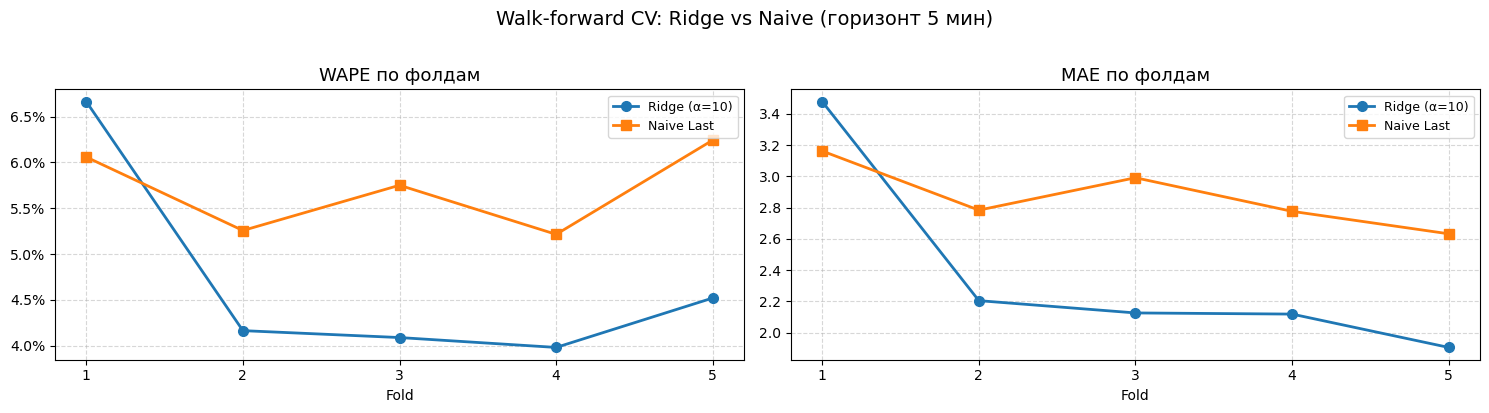

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
folds_x = [r['fold'] for r in results]

colors = {'ridge': '#1f77b4', 'naive_last': '#ff7f0e', 'naive_mean': '#2ca02c'}
markers = {'ridge': 'o', 'naive_last': 's', 'naive_mean': '^'}

for ax, metric in zip(axes, ['WAPE', 'MAE']):
    for m in models:
        vals = [r[m][metric] for r in results]
        lbl = model_labels[m]
        if metric in ('WAPE', 'MAPE'):
            ax.plot(folds_x, vals, label=lbl,
                    color=colors[m], marker=markers[m], linewidth=2, markersize=7)
        else:
            ax.plot(folds_x, vals, label=lbl,
                    color=colors[m], marker=markers[m], linewidth=2, markersize=7)

    ax.set_title(f'{metric} по фолдам', fontsize=13)
    ax.set_xlabel('Fold')
    if metric in ('WAPE', 'MAPE'):
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.set_xticks(folds_x)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Walk-forward CV: Ridge vs Naive (горизонт 5 мин)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. Визуализация прогнозов на последнем фолде


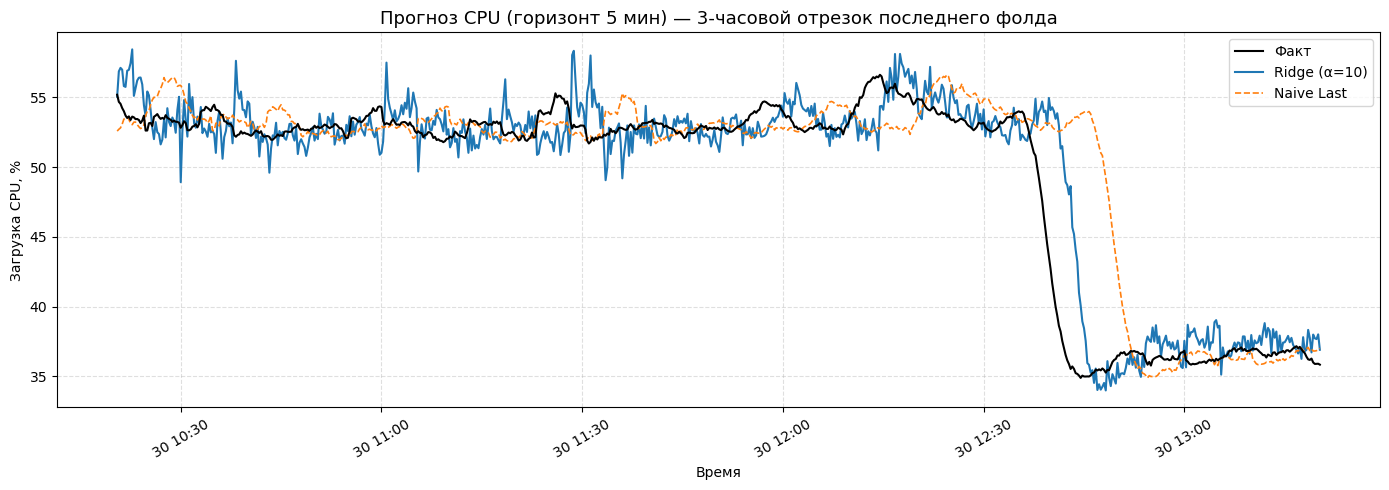

In [50]:
# Показываем случайный 3-часовой отрезок последнего фолда
N_SHOW_STEPS = int(3 * 60 * 60 / FREQ_SEC)   # 720 точек = 3 ч
start_idx = len(all_preds) // 3               # начинаем с 1/3 фолда
plot_slice = all_preds.iloc[start_idx: start_idx + N_SHOW_STEPS]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(plot_slice.index, plot_slice['actual'],
        label='Факт', color='black', linewidth=1.5, zorder=5)
ax.plot(plot_slice.index, plot_slice['ridge'],
        label='Ridge (α=10)', color='#1f77b4', linewidth=1.5, linestyle='-')
ax.plot(plot_slice.index, plot_slice['naive_last'],
        label='Naive Last', color='#ff7f0e', linewidth=1.2, linestyle='--')

ax.set_title('Прогноз CPU (горизонт 5 мин) — 3-часовой отрезок последнего фолда',
             fontsize=13)
ax.set_xlabel('Время')
ax.set_ylabel('Загрузка CPU, %')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


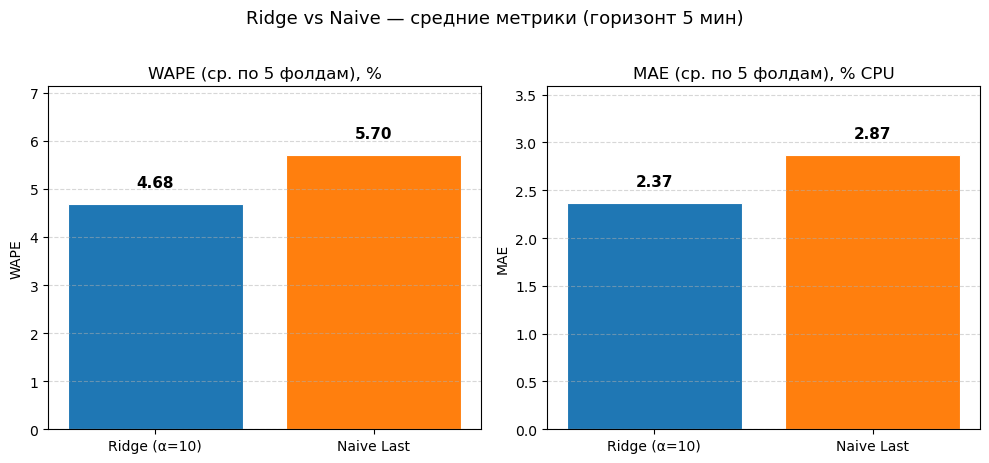

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

labels   = [model_labels[m] for m in models]
bar_clrs = [colors[m] for m in models]

for ax, metric, unit in zip(axes,
                             ['WAPE', 'MAE'],
                             ['%', '% CPU']):
    vals = [summary[m][metric] for m in models]
    bars = ax.bar(labels, vals, color=bar_clrs, edgecolor='white', linewidth=0.8)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05 * max(vals),
                f'{v:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(f'{metric} (ср. по 5 фолдам), {unit}', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Ridge vs Naive — средние метрики (горизонт 5 мин)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 10. Выводы


In [53]:
print('=== ИТОГОВОЕ СРАВНЕНИЕ ===')
print(f'Горизонт прогноза: {FINAL_HORIZON_MIN} мин ({FINAL_HORIZON_STEPS} шагов по {FREQ_SEC} с)')
print(f'Кросс-валидация: walk-forward, {N_FOLDS} фолдов (схема 2)')
print()

for m in models:
    s = summary[m]
    print(f'{model_labels[m]:<18}  WAPE={s["WAPE"]:.2f}%  '
          f'MAE={s["MAE"]:.3f}')

print()
wape_ridge = summary['ridge']['WAPE']
wape_last  = summary['naive_last']['WAPE']
mae_ridge = summary['ridge']['MAE']
mae_last = summary['naive_last']['MAE']

gain_last = (wape_last - wape_ridge) / wape_last * 100
mae_diff = (mae_last - mae_ridge) / mae_last * 100
print(f'Ridge превосходит Naive Last  на {gain_last:.1f}% по WAPE')
print(f'Ridge превосходит Naive Last  на {mae_diff:.1f}% по MAE')


=== ИТОГОВОЕ СРАВНЕНИЕ ===
Горизонт прогноза: 5 мин (20 шагов по 15 с)
Кросс-валидация: walk-forward, 5 фолдов (схема 2)

Ridge (α=10)        WAPE=4.68%  MAE=2.367
Naive Last          WAPE=5.70%  MAE=2.870

Ridge превосходит Naive Last  на 17.9% по WAPE
Ridge превосходит Naive Last  на 17.5% по MAE
